# 📊 Notebook 3 — Exploratory Data Analysis (EDA)
**Goal:** Visualize sales patterns across time, category, region, weather, promotions, pricing, and more.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

df = pd.read_csv('../data/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
print('Shape:', df.shape)
df.head()


Shape: (73100, 25)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Year,Month,Week,DayOfWeek,Quarter,IsWeekend,Category_enc,Region_enc,Weather_Condition_enc,Seasonality_enc
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,2022,1,52,5,1,1,3,1,1,0
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,...,2022,1,52,5,1,1,4,2,3,0
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,...,2022,1,52,5,1,1,4,3,3,2
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,...,2022,1,52,5,1,1,4,1,0,0
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,...,2022,1,52,5,1,1,1,0,3,2


## Analysis 1 — Sales Distribution

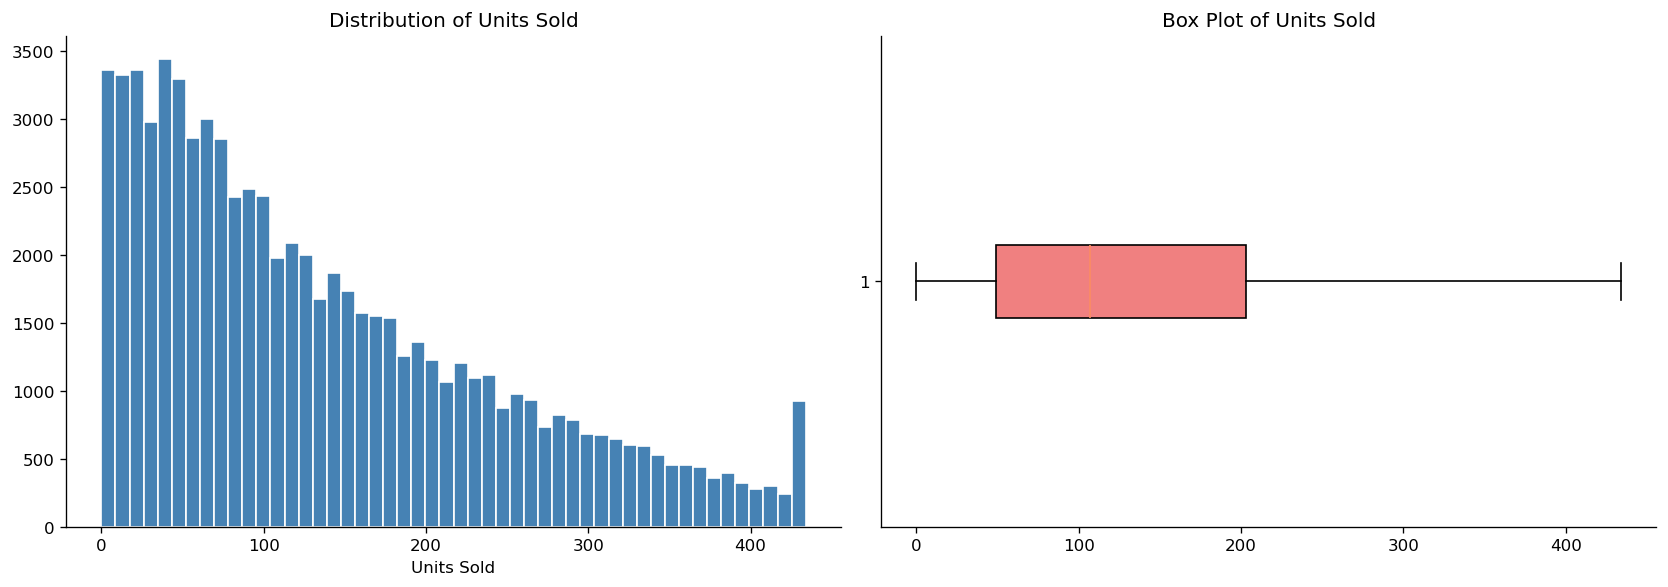

Mean: 136.24
Median: 107.0
Std Dev: 108.27


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Units Sold'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Units Sold')
axes[0].set_xlabel('Units Sold')
axes[1].boxplot(df['Units Sold'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Box Plot of Units Sold')
plt.tight_layout()
plt.savefig('../outputs/plots/01_sales_distribution.png')
plt.show()
print('Mean:', round(df['Units Sold'].mean(), 2))
print('Median:', df['Units Sold'].median())
print('Std Dev:', round(df['Units Sold'].std(), 2))


## Analysis 2 — Monthly Sales Trend

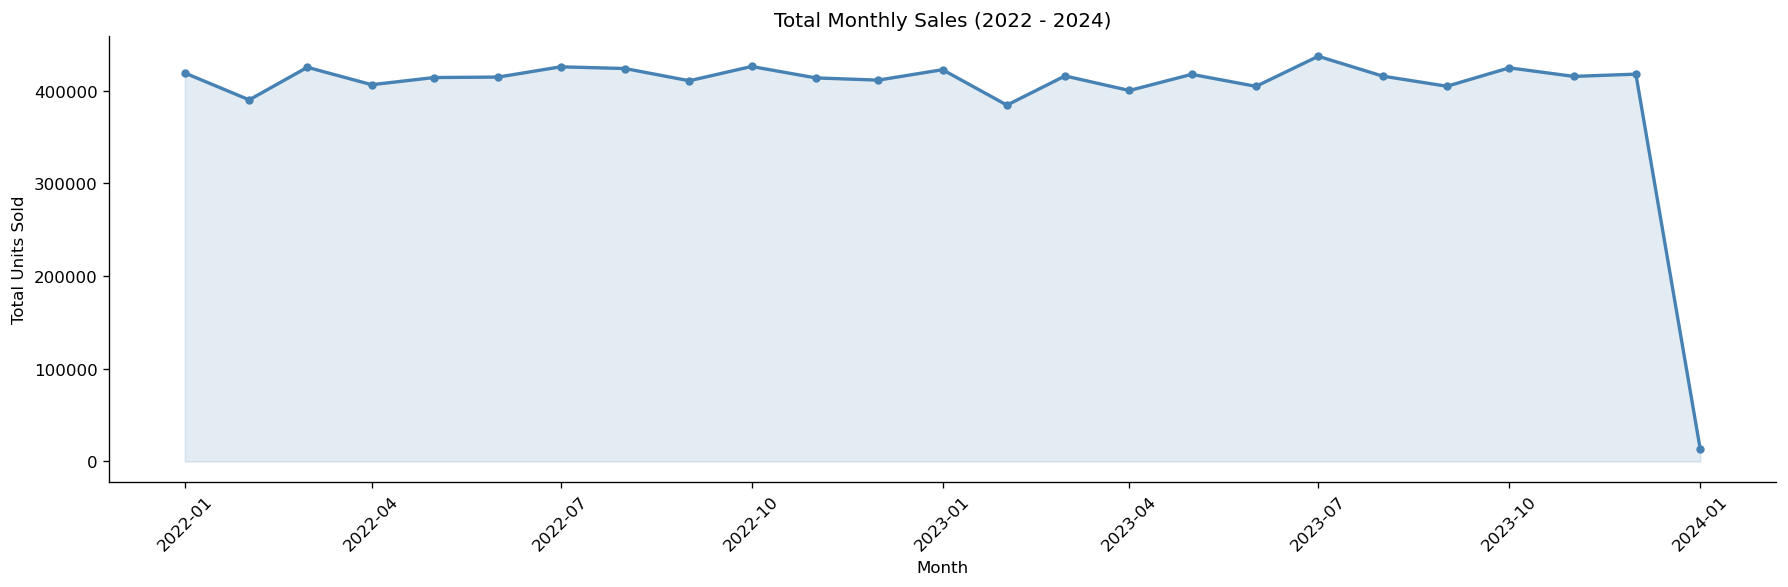

In [3]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Units Sold'].sum().reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()
plt.figure(figsize=(15, 5))
plt.plot(monthly['Date'], monthly['Units Sold'], marker='o', linewidth=2, color='steelblue', markersize=4)
plt.fill_between(monthly['Date'], monthly['Units Sold'], alpha=0.15, color='steelblue')
plt.title('Total Monthly Sales (2022 - 2024)')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/02_monthly_trend.png')
plt.show()


## Analysis 3 — Sales by Month (Seasonality)

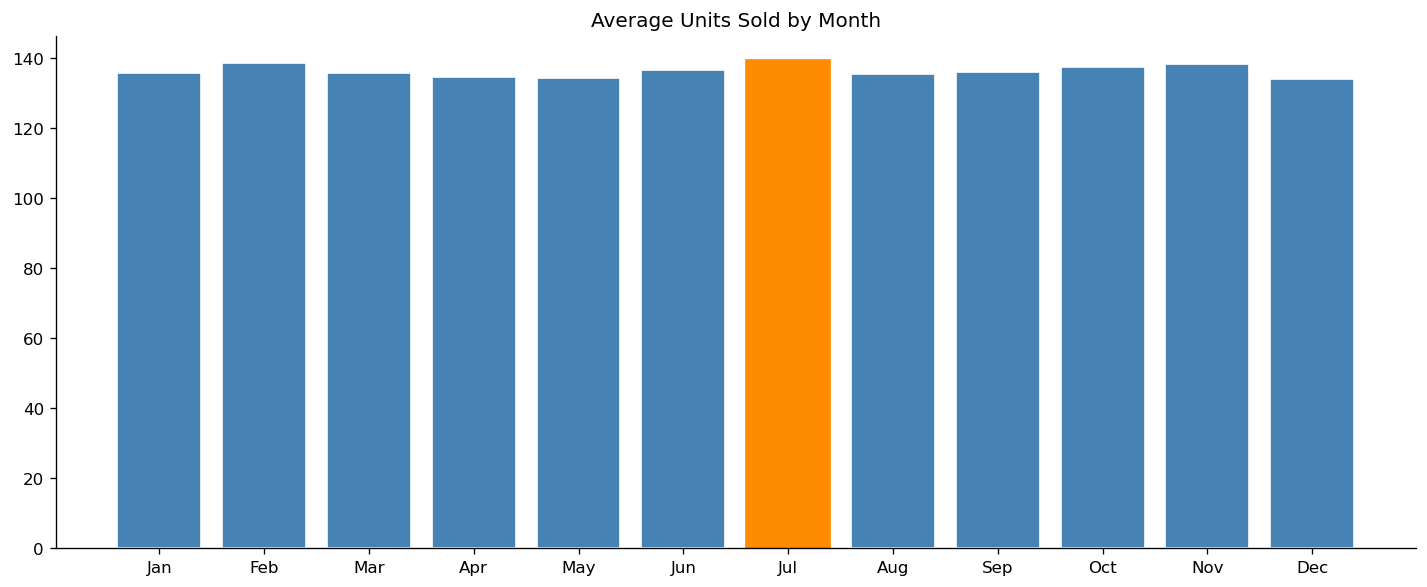

In [4]:
monthly_avg = df.groupby(df['Date'].dt.month)['Units Sold'].mean().reset_index()
monthly_avg.columns = ['Month', 'Avg Units Sold']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['Month Name'] = monthly_avg['Month'].apply(lambda x: month_names[x-1])
plt.figure(figsize=(12, 5))
bars = plt.bar(monthly_avg['Month Name'], monthly_avg['Avg Units Sold'], color='steelblue', edgecolor='white')
bars[monthly_avg['Avg Units Sold'].idxmax()].set_color('darkorange')
plt.title('Average Units Sold by Month')
plt.tight_layout()
plt.savefig('../outputs/plots/03_monthly_seasonality.png')
plt.show()


## Analysis 4 — Sales by Day of Week

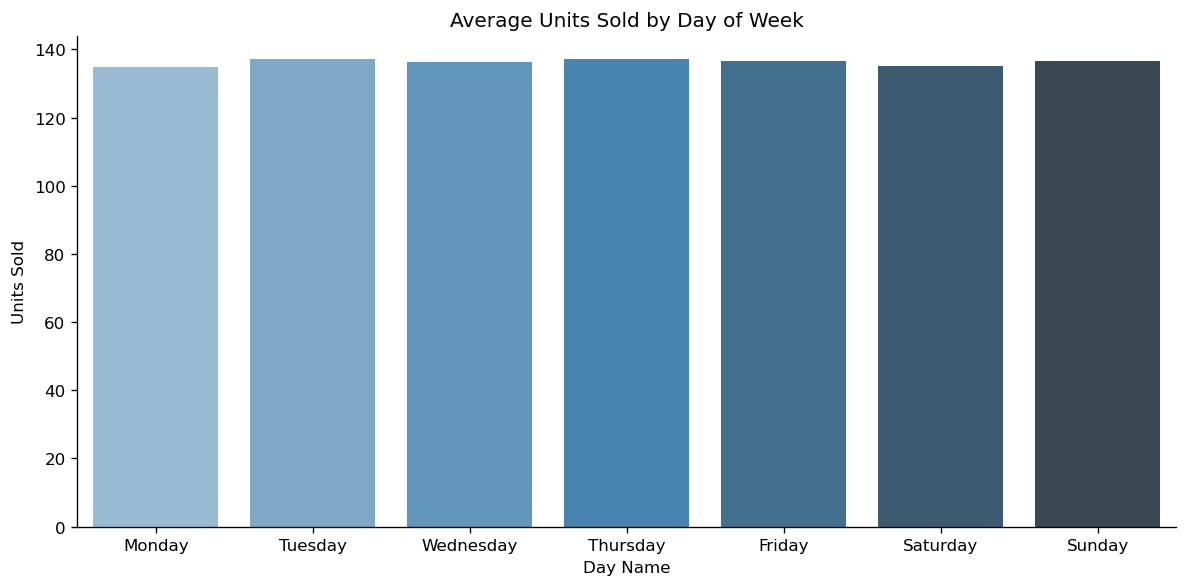

In [5]:
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = df.groupby('DayOfWeek')['Units Sold'].mean().reset_index()
day_avg['Day Name'] = day_avg['DayOfWeek'].apply(lambda x: day_names[x])
plt.figure(figsize=(10, 5))
sns.barplot(data=day_avg, x='Day Name', y='Units Sold', palette='Blues_d')
plt.title('Average Units Sold by Day of Week')
plt.tight_layout()
plt.savefig('../outputs/plots/04_day_of_week.png')
plt.show()


## Analysis 5 — Sales by Category

      Category  Total_Sales   Avg_Sales  Avg_Price
2    Furniture      2021298  137.512620  55.175861
3    Groceries      1996893  136.670522  55.271222
0     Clothing      1996261  136.487146  54.886602
4         Toys      1987655  135.740968  55.032410
1  Electronics      1957182  134.782866  55.310763


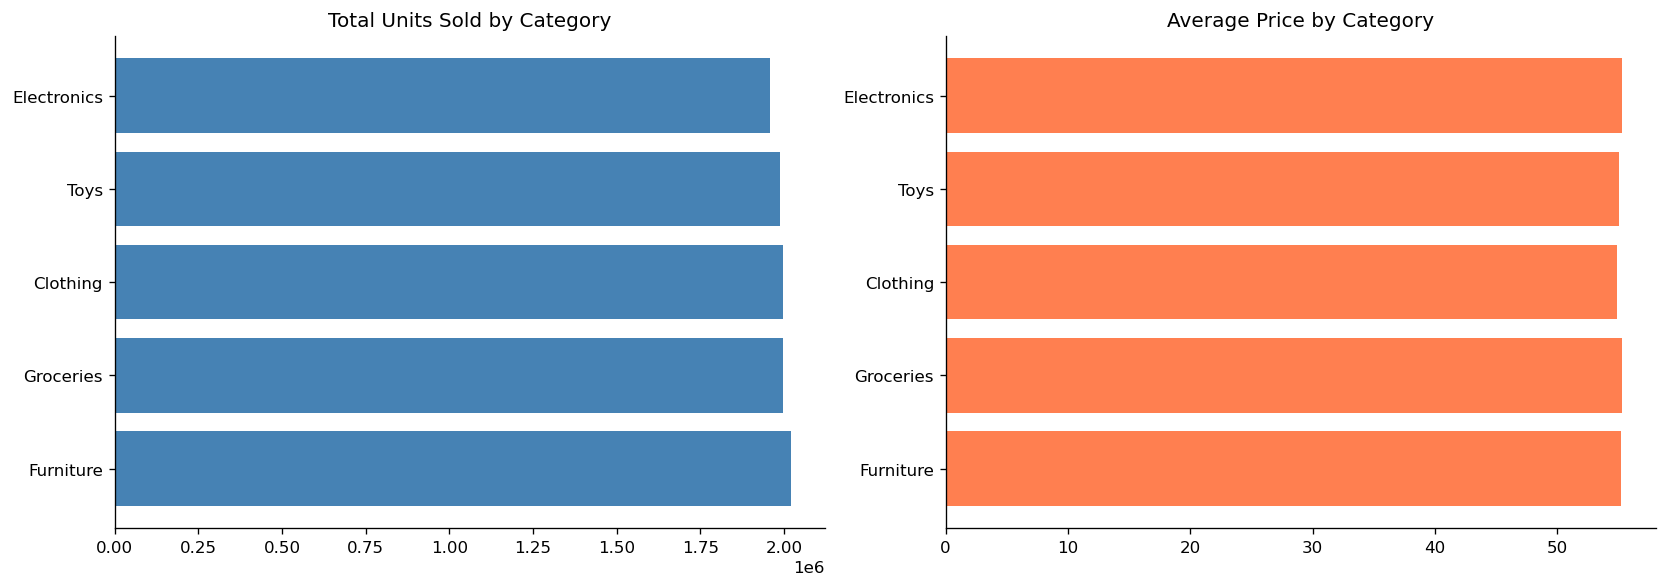

In [6]:
cat_stats = df.groupby('Category').agg(
    Total_Sales=('Units Sold','sum'), Avg_Sales=('Units Sold','mean'), Avg_Price=('Price','mean')
).reset_index().sort_values('Total_Sales', ascending=False)
print(cat_stats)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cat_stats['Category'], cat_stats['Total_Sales'], color='steelblue')
axes[0].set_title('Total Units Sold by Category')
axes[1].barh(cat_stats['Category'], cat_stats['Avg_Price'], color='coral')
axes[1].set_title('Average Price by Category')
plt.tight_layout()
plt.savefig('../outputs/plots/05_category_analysis.png')
plt.show()


## Analysis 6 — Sales by Region

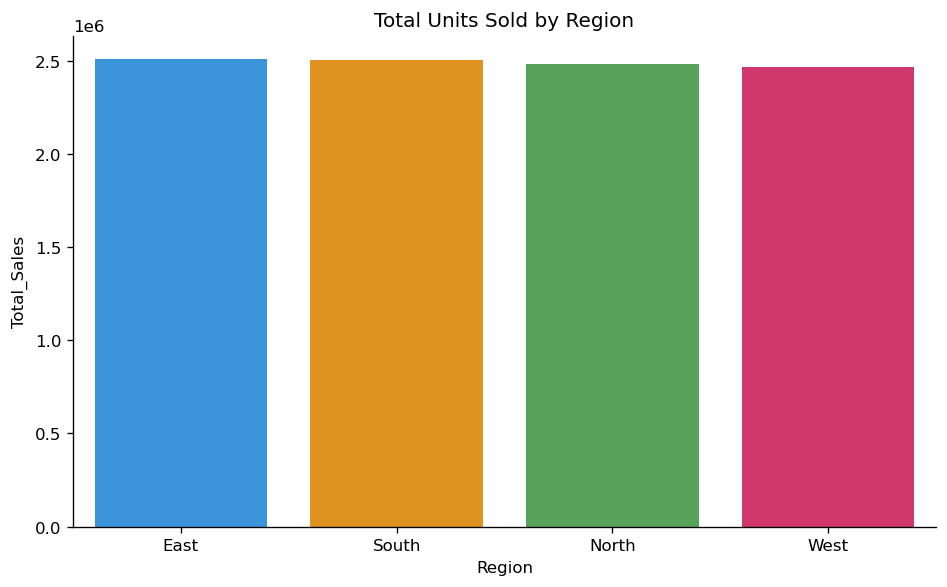

In [7]:
region_stats = df.groupby('Region').agg(Total_Sales=('Units Sold','sum')).reset_index().sort_values('Total_Sales', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=region_stats, x='Region', y='Total_Sales', palette=['#2196F3','#FF9800','#4CAF50','#E91E63'])
plt.title('Total Units Sold by Region')
plt.tight_layout()
plt.savefig('../outputs/plots/06_region_analysis.png')
plt.show()


## Analysis 7 — Category Sales Trend Over Time

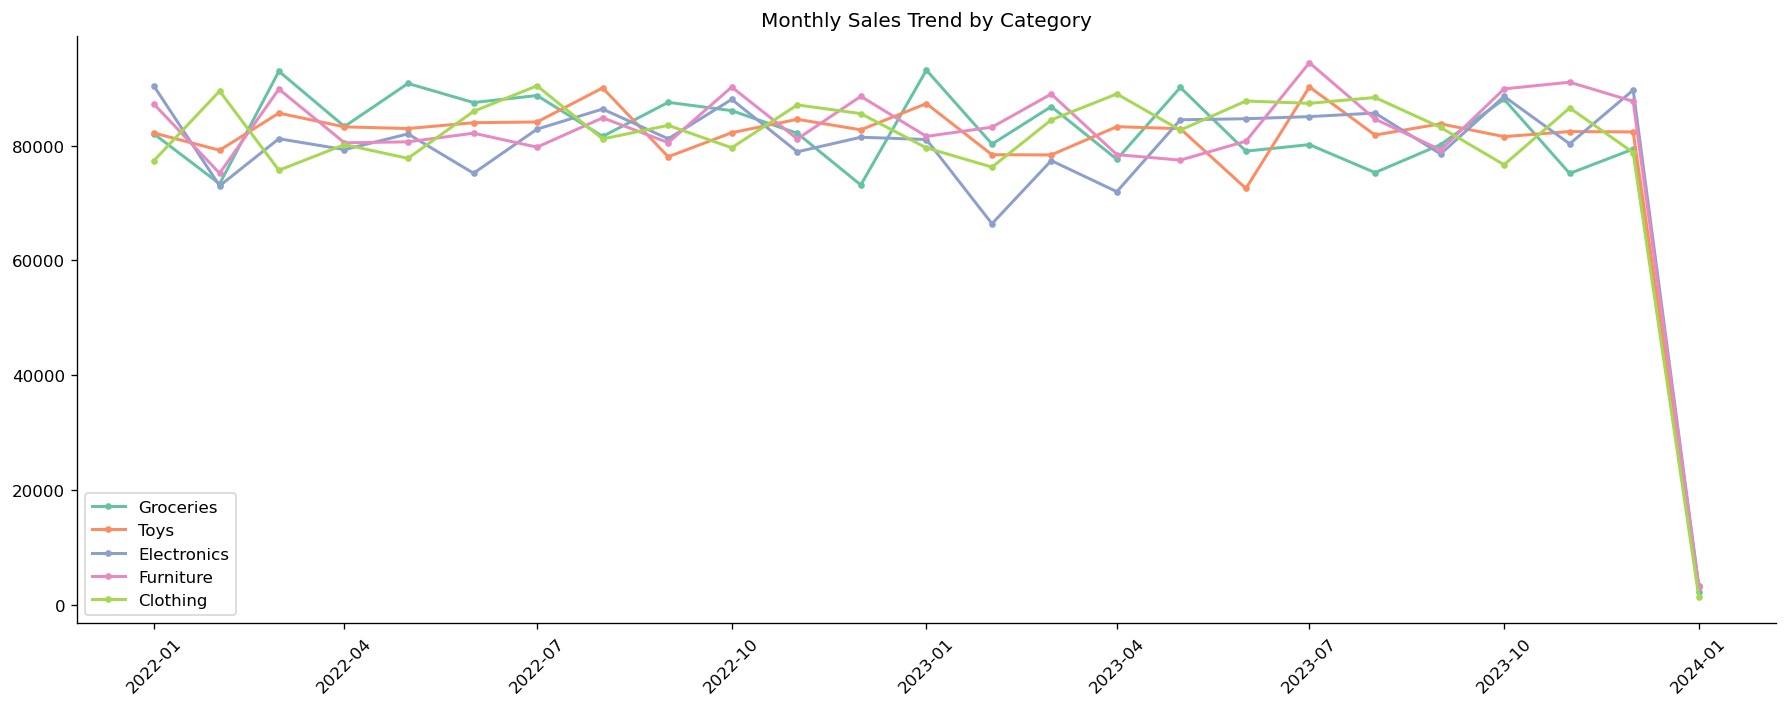

In [8]:
cat_monthly = df.groupby([df['Date'].dt.to_period('M'), 'Category'])['Units Sold'].sum().reset_index()
cat_monthly['Date'] = cat_monthly['Date'].dt.to_timestamp()
plt.figure(figsize=(15, 6))
for cat in df['Category'].unique():
    subset = cat_monthly[cat_monthly['Category'] == cat]
    plt.plot(subset['Date'], subset['Units Sold'], marker='o', markersize=3, linewidth=1.8, label=cat)
plt.title('Monthly Sales Trend by Category')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/07_category_trend.png')
plt.show()


## Analysis 8 — Effect of Discount on Sales

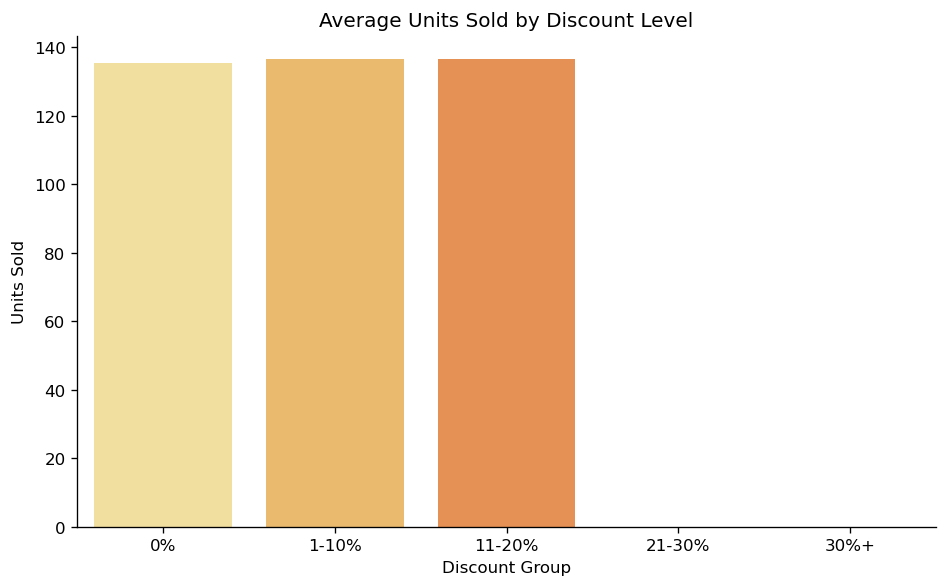

In [9]:
df['Discount Group'] = pd.cut(df['Discount'], bins=[-1,0,10,20,30,100], labels=['0%','1-10%','11-20%','21-30%','30%+'])
disc_stats = df.groupby('Discount Group', observed=True)['Units Sold'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=disc_stats, x='Discount Group', y='Units Sold', palette='YlOrRd', order=['0%','1-10%','11-20%','21-30%','30%+'])
plt.title('Average Units Sold by Discount Level')
plt.tight_layout()
plt.savefig('../outputs/plots/08_discount_effect.png')
plt.show()


## Analysis 9 — Weather Effect on Sales

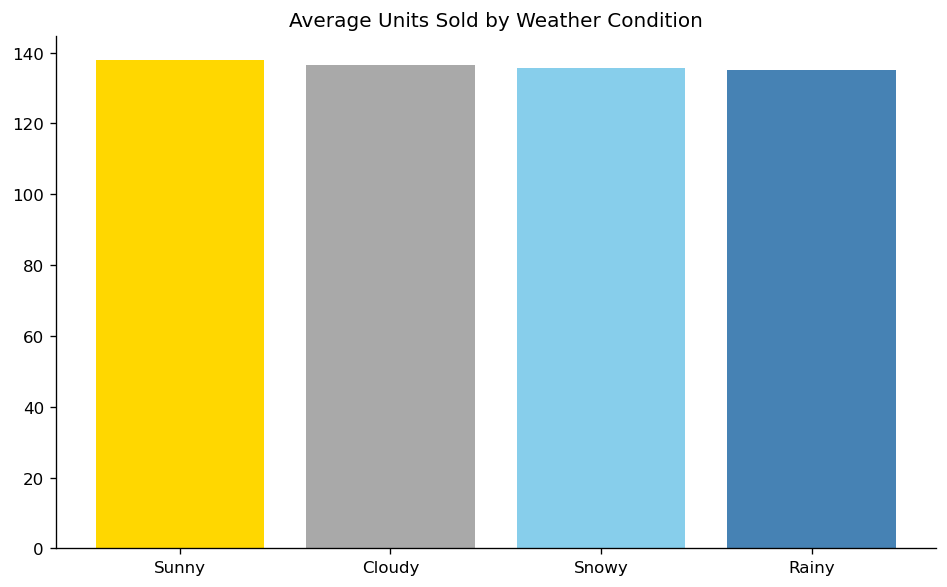

  Weather Condition  Units Sold
0             Sunny  137.803773
1            Cloudy  136.519113
2             Snowy  135.680221
3             Rainy  134.963891


In [10]:
weather_stats = df.groupby('Weather Condition')['Units Sold'].mean().sort_values(ascending=False).reset_index()
colors = {'Sunny':'#FFD700', 'Rainy':'#4682B4', 'Cloudy':'#A9A9A9', 'Snowy':'#87CEEB'}
bar_colors = [colors.get(w, 'steelblue') for w in weather_stats['Weather Condition']]
plt.figure(figsize=(8,5))
plt.bar(weather_stats['Weather Condition'], weather_stats['Units Sold'], color=bar_colors)
plt.title('Average Units Sold by Weather Condition')
plt.tight_layout()
plt.savefig('../outputs/plots/09_weather_effect.png')
plt.show()
print(weather_stats)


## Analysis 10 — Holiday / Promotion Impact

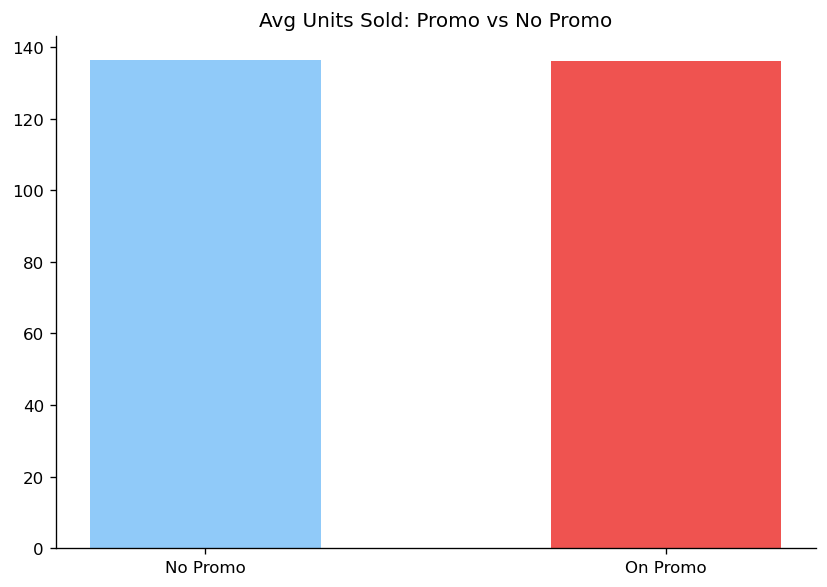

  Holiday/Promotion  Units Sold
0          No Promo  136.267450
1          On Promo  136.216241


In [11]:
holiday_stats = df.groupby('Holiday/Promotion')['Units Sold'].mean().reset_index()
holiday_stats['Holiday/Promotion'] = holiday_stats['Holiday/Promotion'].map({0:'No Promo', 1:'On Promo'})
plt.figure(figsize=(7,5))
plt.bar(holiday_stats['Holiday/Promotion'], holiday_stats['Units Sold'], color=['#90CAF9','#EF5350'], width=0.5)
plt.title('Avg Units Sold: Promo vs No Promo')
plt.tight_layout()
plt.savefig('../outputs/plots/10_holiday_effect.png')
plt.show()
print(holiday_stats)


## Analysis 11 — Seasonality

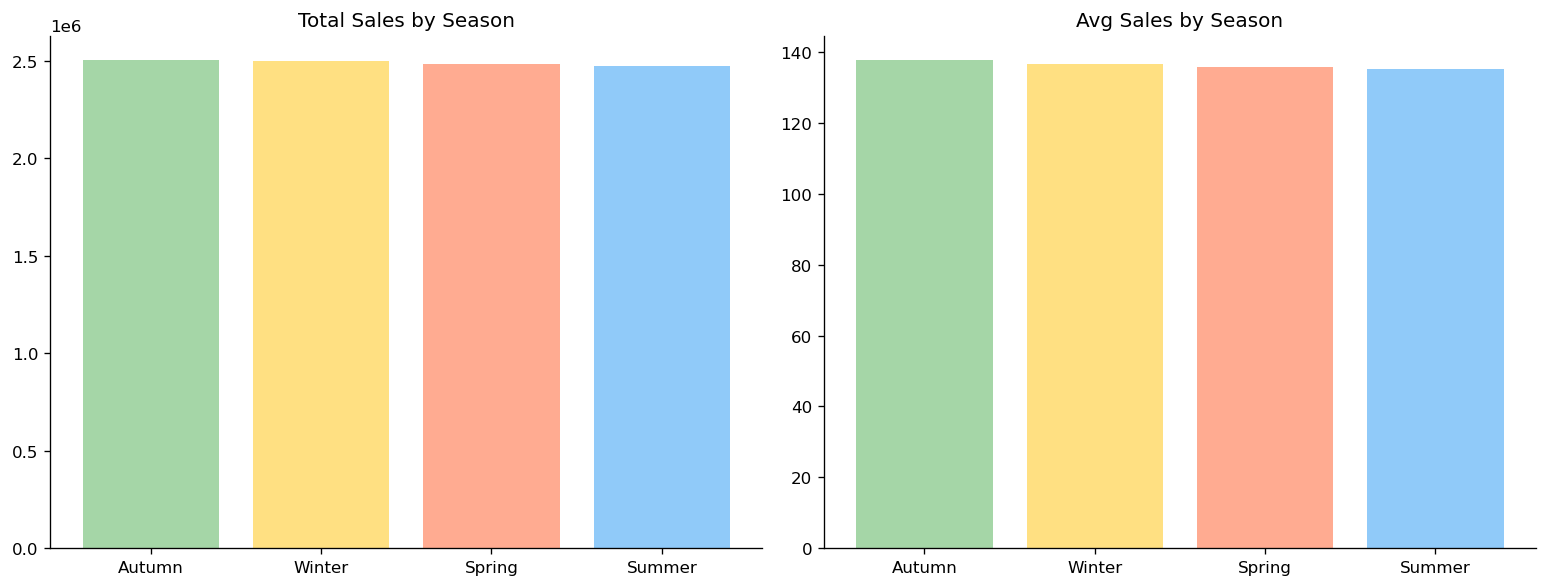

In [12]:
season_stats = df.groupby('Seasonality')['Units Sold'].agg(['mean','sum']).reset_index().sort_values('sum', ascending=False)
season_stats.columns = ['Season','Avg Sales','Total Sales']
fig, axes = plt.subplots(1, 2, figsize=(13,5))
colors = ['#A5D6A7','#FFE082','#FFAB91','#90CAF9']
axes[0].bar(season_stats['Season'], season_stats['Total Sales'], color=colors)
axes[0].set_title('Total Sales by Season')
axes[1].bar(season_stats['Season'], season_stats['Avg Sales'], color=colors)
axes[1].set_title('Avg Sales by Season')
plt.tight_layout()
plt.savefig('../outputs/plots/11_seasonality.png')
plt.show()


## Analysis 12 — Price vs Sales Scatter

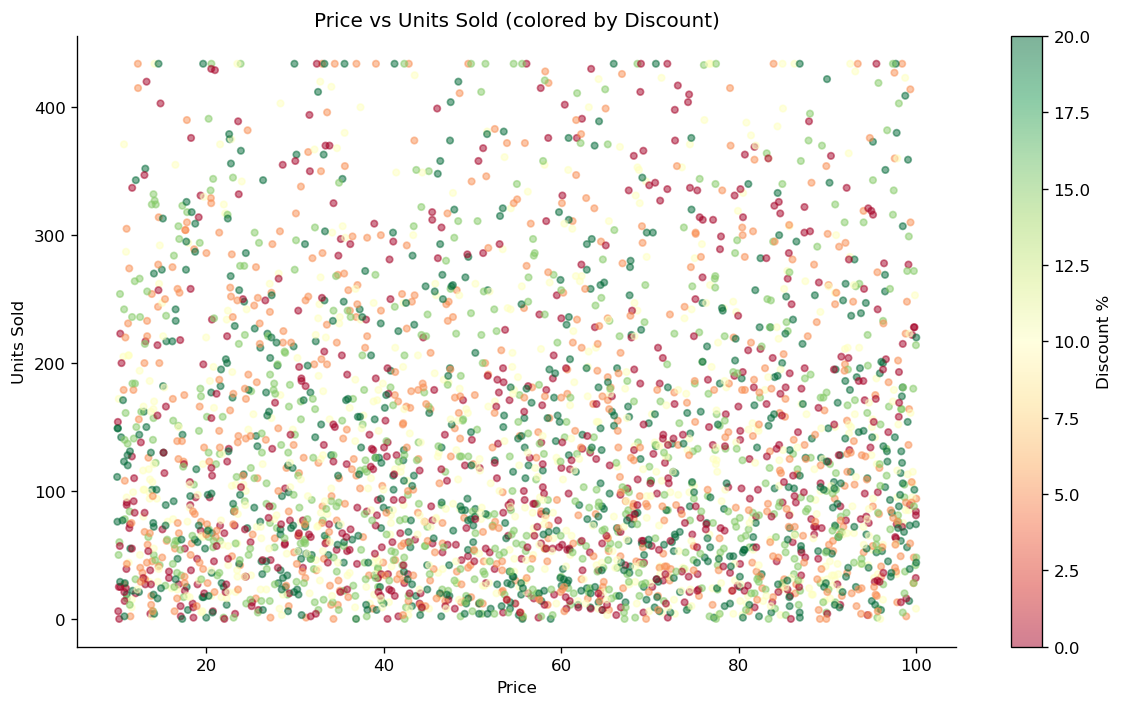

In [13]:
sample = df.sample(3000, random_state=42)
plt.figure(figsize=(10,6))
scatter = plt.scatter(sample['Price'], sample['Units Sold'], c=sample['Discount'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(scatter, label='Discount %')
plt.title('Price vs Units Sold (colored by Discount)')
plt.xlabel('Price')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('../outputs/plots/12_price_vs_sales.png')
plt.show()


## Analysis 13 — Competitor Pricing vs Our Sales

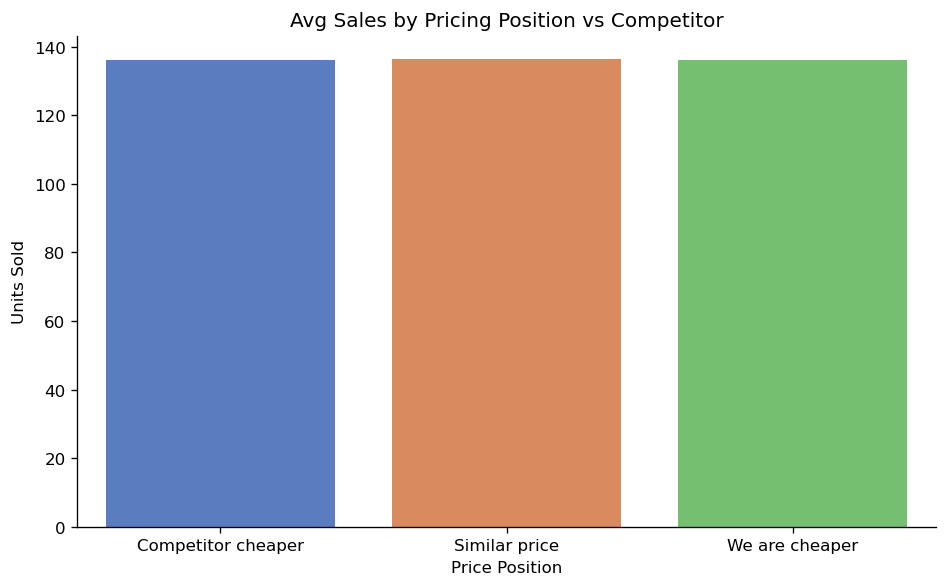

In [14]:
df['Price Diff'] = df['Price'] - df['Competitor Pricing']
df['Price Position'] = df['Price Diff'].apply(
    lambda x: 'We are cheaper' if x < -2 else ('Similar price' if -2 <= x <= 2 else 'Competitor cheaper'))
pos_stats = df.groupby('Price Position')['Units Sold'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=pos_stats, x='Price Position', y='Units Sold', palette='muted')
plt.title('Avg Sales by Pricing Position vs Competitor')
plt.tight_layout()
plt.savefig('../outputs/plots/13_competitor_pricing.png')
plt.show()


## Analysis 14 — Inventory Level vs Sales

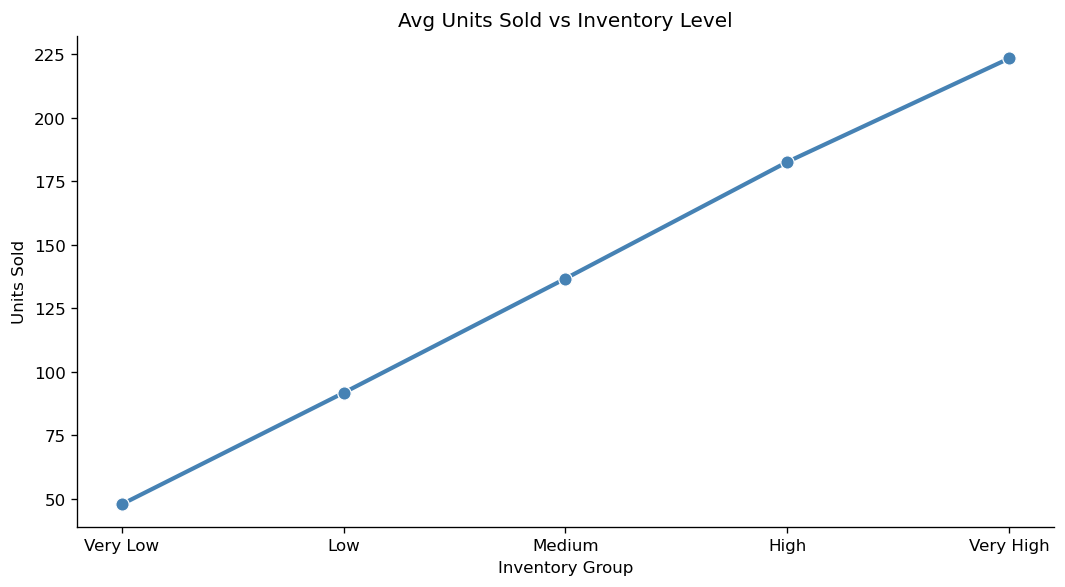

In [15]:
df['Inventory Group'] = pd.qcut(df['Inventory Level'], q=5, labels=['Very Low','Low','Medium','High','Very High'])
inv_stats = df.groupby('Inventory Group', observed=True)['Units Sold'].mean().reset_index()
plt.figure(figsize=(9,5))
sns.lineplot(data=inv_stats, x='Inventory Group', y='Units Sold', marker='o', linewidth=2.5, color='steelblue', markersize=8)
plt.title('Avg Units Sold vs Inventory Level')
plt.tight_layout()
plt.savefig('../outputs/plots/14_inventory_vs_sales.png')
plt.show()


## Analysis 15 — Correlation Heatmap

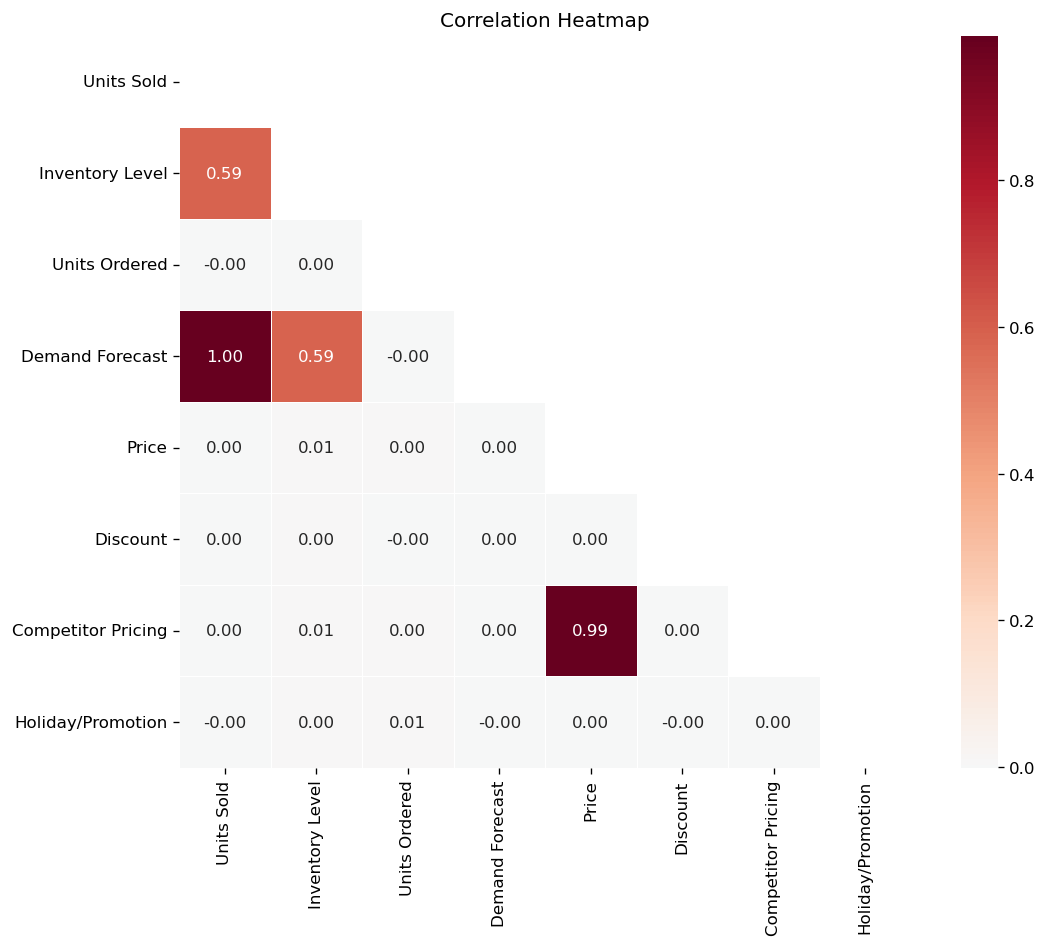


Correlation with Units Sold:
Units Sold            1.000000
Demand Forecast       0.996565
Inventory Level       0.590190
Discount              0.002404
Competitor Pricing    0.001441
Price                 0.001284
Holiday/Promotion    -0.000236
Units Ordered        -0.000938
Name: Units Sold, dtype: float64


In [16]:
num_cols = ['Units Sold','Inventory Level','Units Ordered','Demand Forecast','Price','Discount','Competitor Pricing','Holiday/Promotion']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/plots/15_correlation_heatmap.png')
plt.show()
print('\nCorrelation with Units Sold:')
print(corr['Units Sold'].sort_values(ascending=False))


## Analysis 16 — Top Products by Sales

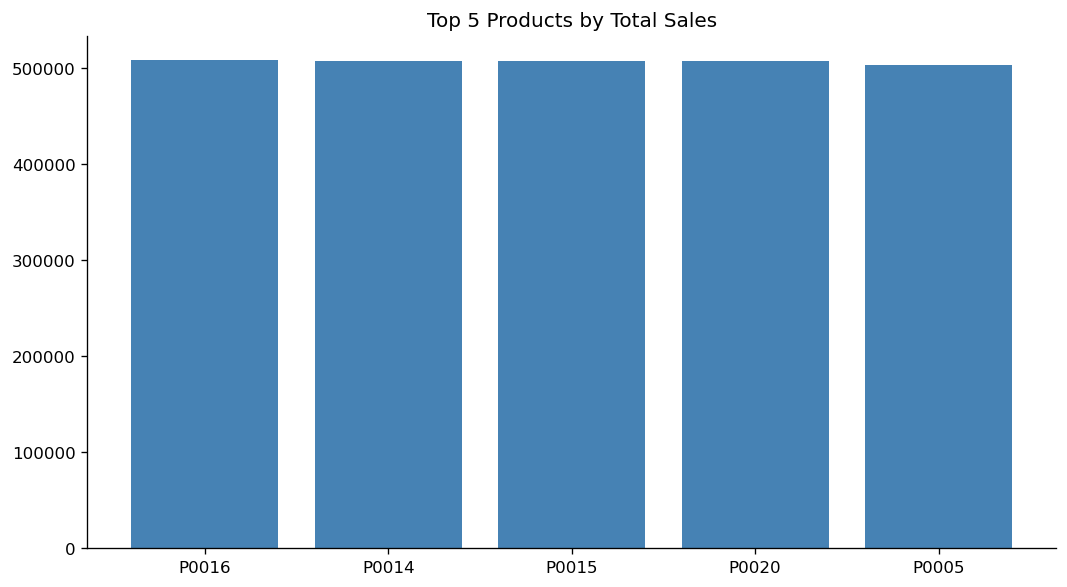

  Product ID  Units Sold
0      P0016      507640
1      P0014      506817
2      P0015      506816
3      P0020      506714
4      P0005      502977


In [17]:
top_products = df.groupby('Product ID')['Units Sold'].sum().sort_values(ascending=False).head(5).reset_index()
plt.figure(figsize=(9,5))
plt.bar(top_products['Product ID'], top_products['Units Sold'], color='steelblue')
plt.title('Top 5 Products by Total Sales')
plt.tight_layout()
plt.savefig('../outputs/plots/16_top_products.png')
plt.show()
print(top_products)


## Analysis 17 — Category × Month Heatmap

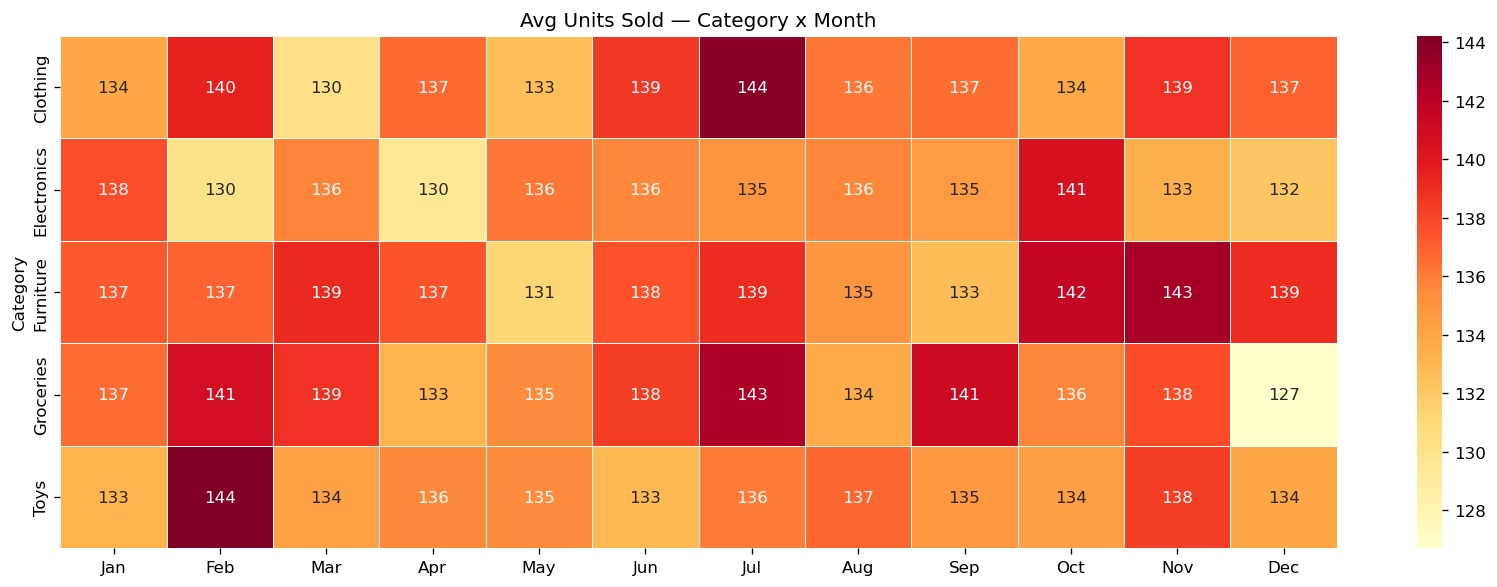

In [18]:
pivot = df.pivot_table(values='Units Sold', index='Category', columns=df['Date'].dt.month, aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Avg Units Sold — Category x Month')
plt.tight_layout()
plt.savefig('../outputs/plots/17_category_month_heatmap.png')
plt.show()


## Analysis 18 — EDA Summary

In [19]:
print('='*55)
print('       EDA SUMMARY')
print('='*55)
print(f'Total records       : {len(df):,}')
print(f'Date range          : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Avg Units Sold/day  : {df["Units Sold"].mean():.1f}')
print(f'Avg Price           : {df["Price"].mean():.2f}')
print(f'Avg Discount        : {df["Discount"].mean():.1f}%')
print(f'Promo days          : {df["Holiday/Promotion"].mean()*100:.1f}% of records')
print(f'Top category        : {df.groupby("Category")["Units Sold"].sum().idxmax()}')
print(f'Top region          : {df.groupby("Region")["Units Sold"].sum().idxmax()}')
print(f'Best season         : {df.groupby("Seasonality")["Units Sold"].mean().idxmax()}')
print('='*55)


       EDA SUMMARY
Total records       : 73,100
Date range          : 2022-01-01 to 2024-01-01
Avg Units Sold/day  : 136.2
Avg Price           : 55.14
Avg Discount        : 10.0%
Promo days          : 49.7% of records
Top category        : Furniture
Top region          : East
Best season         : Autumn
